# 9. Interpretabilidad con LIME

Sección 9.10.4.7 del enunciado. LIME (*Local Interpretable Model-agnostic Explanations*, Ribeiro,
Singh y Guestrin, 2016) explica una predicción individual: genera perturbaciones alrededor de la
instancia, obtiene la probabilidad que el modelo asigna a cada perturbación y ajusta un modelo
lineal ponderado por cercanía. Los coeficientes de ese modelo local indican cuánto empuja cada
condición la probabilidad de default **para esa instancia**.

Se explica el modelo con mayor AUC de cada entorno entre los que entregan probabilidades
(`LinearSVC` no las produce), sobre dos préstamos del conjunto de prueba que **ambos** modelos
clasificaron mal en su umbral de Youden: un default que se predijo como pagado (falso negativo) y
un préstamo pagado que se predijo como default (falso positivo).

Para que las explicaciones se lean en unidades originales (tasa en %, FICO en puntos...), LIME
trabaja sobre las variables imputadas **sin escalar** y la función de predicción aplica el
escalado aprendido en entrenamiento antes de llamar al modelo.

In [1]:
import sys
import time
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer

import features as fe
import modelado as mo
import utils as u

u.estilo()
pd.set_option("display.max_columns", 20, "display.width", 180, "display.max_colwidth", 60)
N_MUESTRAS_LIME = 5000
N_VARIABLES = 10

res = {e: {m: mo.cargar_resultado(e, m) for m in mo.ORDEN} for e in ("sklearn", "spark")}
mejor = {e: max((m for m in mo.ORDEN if m != "LinearSVC"),
                key=lambda m: res[e][m]["metricas_youden"]["auc_roc"]) for e in res}
for e, m in mejor.items():
    print(f"{e}: {m} (AUC {res[e][m]['metricas_youden']['auc_roc']:.4f}, "
          f"umbral {res[e][m]['umbral_youden']:.4f}, parámetros {res[e][m]['mejores_parametros']})")

sklearn: GradientBoosting (AUC 0.7235, umbral 0.1985, parámetros {'max_depth': 5, 'n_estimators': 100})
spark: GradientBoosting (AUC 0.7228, umbral 0.1980, parámetros {'maxIter': 100, 'maxDepth': 5})


## 9.1 Selección de las instancias mal clasificadas

In [2]:
sk = mo.leer_puntuaciones("sklearn")[["id", "default", mejor["sklearn"]]].rename(columns={mejor["sklearn"]: "s_sk"})
sp = mo.leer_puntuaciones("spark")[["id", "default", mejor["spark"]]].rename(columns={mejor["spark"]: "s_sp"})
p = sk.merge(sp, on=["id", "default"])
u_sk, u_sp = res["sklearn"][mejor["sklearn"]]["umbral_youden"], res["spark"][mejor["spark"]]["umbral_youden"]
p["pred_sk"], p["pred_sp"] = (p["s_sk"] >= u_sk).astype(int), (p["s_sp"] >= u_sp).astype(int)
fn = p[(p["default"] == 1) & (p["pred_sk"] == 0) & (p["pred_sp"] == 0)]
fp = p[(p["default"] == 0) & (p["pred_sk"] == 1) & (p["pred_sp"] == 1)]
print(f"Falsos negativos comunes: {len(fn):,} | falsos positivos comunes: {len(fp):,}")
# El error más claro de cada tipo según el promedio de rangos de ambos modelos
p["rango"] = (p["s_sk"].rank(pct=True) + p["s_sp"].rank(pct=True)) / 2
fila_fn = p.loc[fn.index, "rango"].idxmin()
fila_fp = p.loc[fp.index, "rango"].idxmax()
casos = p.loc[[fila_fn, fila_fp]].assign(tipo=["falso negativo", "falso positivo"])
casos

Falsos negativos comunes: 16,305 | falsos positivos comunes: 70,415


,id,default,s_sk,s_sp,pred_sk,pred_sp,rango,tipo
222478,94465383,1,0.019804,0.022243,0,0,0.000193,falso negativo
79175,28762783,0,0.768490,0.768179,1,1,0.999943,falso positivo


In [3]:
base = pd.read_parquet(u.MODELO)
base[base["id"].isin(casos["id"])].set_index("id").loc[casos["id"]].T

id,94465383,28762783
default,1,0
loan_amnt,10000.0,21975.0
term,36.0,60.0
int_rate,5.32,24.5
emp_length,2.0,5.0
annual_inc,12.765691,10.819798
dti,6.57,28.66
fico_range_high,774.0,674.0
delinq_2yrs,0.0,0.0
inq_last_6mths,0.0,0.0


En ambos entornos el mejor modelo con probabilidades es el gradient boosting (100 árboles de
profundidad 5). De los préstamos de prueba, 16.305 son falsos negativos y 70.415 falsos positivos
**de los dos** modelos a la vez; se elige el error más claro de cada tipo según el rango promedio
de sus puntuaciones:

* **Falso negativo** (id 94465383): préstamo de 10.000 dólares a 36 meses con tasa de 5,32 %,
  FICO de 774, ingreso anual de 350.000 dólares, `dti` de 6,6 y cinco cuentas hipotecarias. Ambos
  modelos le asignan una probabilidad de default de 2 %, y aun así incumplió. Ninguno de los dos lo
  anticipó a partir del perfil de originación; es posible que el impago se debiera a un hecho
  posterior (pérdida de empleo, enfermedad) que no está en los datos.
* **Falso positivo** (id 28762783): préstamo de 21.975 dólares a 60 meses con tasa de 24,5 %, FICO
  de 674, `dti` de 28,7, ingreso de 50.000 dólares, en arriendo y con un límite rotativo de solo
  2.500 dólares. Los dos modelos le asignan una probabilidad de 77 %, y se pagó por completo.

Las variables `annual_inc`, `total_rev_hi_lim` y `avg_cur_bal` están en escala $\log(1+x)$: por
ejemplo, `annual_inc > 11.41` equivale a un ingreso mayor que 90.000 dólares.

## 9.2 LIME sobre el modelo de scikit-learn

In [4]:
d = fe.preparar_sklearn()
ct = d["ct"]
esc = ct.named_transformers_["num"].named_steps["standardscaler"]
k = len(fe.NUM_IND)
nombres = d["nombres"]


def desescalar(X):
    Z = X.copy()
    Z[:, :k] = Z[:, :k] * esc.scale_ + esc.mean_
    return Z


def escalar(Z):
    X = np.array(Z, dtype=float, copy=True)
    X[:, :k] = (X[:, :k] - esc.mean_) / esc.scale_
    return X


modelo_sk = joblib.load(u.MODELOS / f"sklearn_{mejor['sklearn']}.joblib")
predecir_sk = lambda Z: modelo_sk.predict_proba(escalar(Z))
categoricas = [i for i, n in enumerate(nombres) if i >= k or n in fe.IND]
t0 = time.time()
expl_sk = LimeTabularExplainer(desescalar(d["X_train"]), feature_names=nombres,
                               class_names=["pagado", "default"], categorical_features=categoricas,
                               discretize_continuous=True, discretizer="quartile",
                               random_state=u.SEMILLA, mode="classification")
print(f"Explicador construido con {d['X_train'].shape[0]:,} filas de entrenamiento en {time.time() - t0:.1f} s")
pos = {i: np.flatnonzero(d["id_test"] == i)[0] for i in casos["id"]}

exp_sk, t_lime = {}, {}
for _, c in casos.iterrows():
    x = desescalar(d["X_test"][[pos[c["id"]]]])[0]
    t0 = time.time()
    exp_sk[c["tipo"]] = expl_sk.explain_instance(x, predecir_sk, num_features=N_VARIABLES,
                                                 num_samples=N_MUESTRAS_LIME)
    t_lime[("sklearn", c["tipo"])] = time.time() - t0
    print(f"{c['tipo']}: P(default) del modelo = {predecir_sk(x[None, :])[0, 1]:.4f}, "
          f"modelo local = {exp_sk[c['tipo']].local_pred[0]:.4f}, R² local = {exp_sk[c['tipo']].score:.3f}, "
          f"tiempo {t_lime[('sklearn', c['tipo'])]:.1f} s")

Explicador construido con 1,078,447 filas de entrenamiento en 9.9 s
falso negativo: P(default) del modelo = 0.0198, modelo local = 0.0265, R² local = 0.447, tiempo 0.0 s
falso positivo: P(default) del modelo = 0.7685, modelo local = 0.4583, R² local = 0.544, tiempo 0.0 s


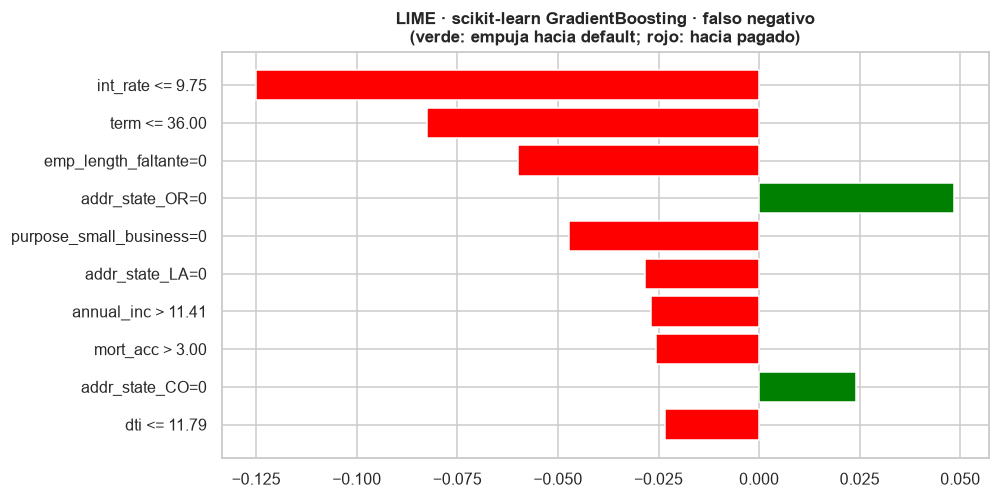

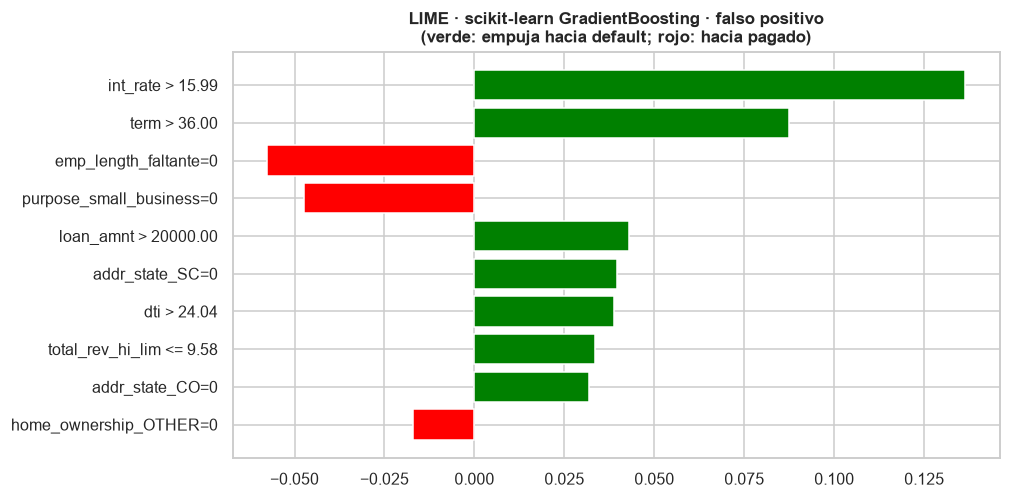

In [5]:
for tipo, ex in exp_sk.items():
    fig = ex.as_pyplot_figure(label=1)
    fig.set_size_inches(9, 4.8)
    plt.title(f"LIME · scikit-learn {mejor['sklearn']} · {tipo}\n(verde: empuja hacia default; rojo: hacia pagado)")
    u.guardar_fig(fig, f"09_lime_sklearn_{tipo.replace(' ', '_')}")
    plt.show()

**Falso negativo.** LIME atribuye la baja probabilidad, sobre todo, a la tasa de interés baja
(`int_rate <= 9.75`, el cuartil inferior, con el mayor peso), al plazo de 36 meses, a que la
antigüedad laboral está informada, al propósito (no es `small_business`), al ingreso alto, a
las cuentas hipotecarias y al `dti` bajo. Son exactamente los factores de bajo riesgo que el EDA
identificó: el modelo razona como se espera y el error no se debe a una regla absurda, sino a
que el préstamo era de bajo riesgo según la información disponible.

**Falso positivo.** Hacia el default empujan, sobre todo, la tasa de interés alta
(`int_rate > 15.99`, el cuartil superior; peso 0,136) y el plazo de 60 meses (0,088), y con pesos
menores el monto alto, el `dti` alto y el límite rotativo bajo (0,034 a 0,043): el perfil típico
de un default. En sentido contrario pesan la antigüedad laboral informada y el propósito. El préstamo se pagó, lo que recuerda que un AUC de 0,72 deja mucha incertidumbre
individual.

El $R^2$ del modelo lineal local es de 0,45 y 0,54: la aproximación lineal captura alrededor de la
mitad de la variación de la probabilidad del gradient boosting en el vecindario de cada préstamo.
Las explicaciones son orientativas, no una descomposición exacta.

## 9.3 LIME sobre el modelo de PySpark

LIME necesita, en la memoria local del driver, (a) datos de entrenamiento para calcular los
cuartiles y frecuencias con los que perturba y (b) una función que reciba una matriz de NumPy y
devuelva probabilidades. Con Spark ambas cosas exigen sacar datos del entorno distribuido:

* Como datos de referencia se toma una muestra aleatoria de 50.000 filas del entrenamiento ya
  transformado (después de entrenar, lo que el enunciado permite) en lugar del millón completo.
* La función de predicción convierte cada lote de 5.000 perturbaciones en un DataFrame de Spark,
  aplica el modelo (`transform`) y devuelve la columna `probability` al driver.

In [6]:
import spark_utils as su
from pyspark.ml import classification as cl
from pyspark.ml.functions import vector_to_array
from pyspark.ml.linalg import Vectors
from pyspark.sql import functions as F

spark = su.sesion_spark()
datos = su.preparar_spark(spark)
datos["base"].unpersist()
clase = {"LogisticRegression": cl.LogisticRegressionModel, "DecisionTree": cl.DecisionTreeClassificationModel,
         "RandomForest": cl.RandomForestClassificationModel, "GradientBoosting": cl.GBTClassificationModel,
         "NaiveBayes": cl.NaiveBayesModel}[mejor["spark"]]
modelo_sp = clase.load(str(u.MODELOS / f"spark_{mejor['spark']}"))
esc_sp = datos["pipeline"].stages[2]
media_sp, desv_sp = esc_sp.mean.toArray(), esc_sp.std.toArray()
nombres_sp = [n.replace("_ohe_", "_") if "_ohe_" in n else fe.NUM_IND[i] for i, n in enumerate(datos["nombres"])]
print("Mismo orden de columnas que en scikit-learn:", nombres_sp == nombres)

frac = min(1.0, 50_000 / datos["n_train"])
ref = datos["train"].sample(fraction=frac, seed=u.SEMILLA).select(vector_to_array("features").alias("f")).toPandas()
X_ref = np.vstack(ref["f"].to_numpy())
X_ref[:, :k] = X_ref[:, :k] * desv_sp + media_sp
print(f"Muestra de referencia transferida al driver: {X_ref.shape}")


def predecir_sp(Z):
    X = np.array(Z, dtype=float, copy=True)
    X[:, :k] = (X[:, :k] - media_sp) / desv_sp
    df = spark.createDataFrame([(Vectors.dense(f),) for f in X], ["features"])
    out = modelo_sp.transform(df).select(vector_to_array("probability").alias("p")).toPandas()
    return np.vstack(out["p"].to_numpy())


expl_sp = LimeTabularExplainer(X_ref, feature_names=nombres_sp, class_names=["pagado", "default"],
                               categorical_features=categoricas, discretize_continuous=True,
                               discretizer="quartile", random_state=u.SEMILLA, mode="classification")
filas = (datos["test"].filter(F.col("id").isin([int(i) for i in casos["id"]]))
         .select("id", vector_to_array("features").alias("f")).collect())
x_sp = {r["id"]: np.array(r["f"]) for r in filas}
exp_sp = {}
for _, c in casos.iterrows():
    x = x_sp[c["id"]].copy()
    x[:k] = x[:k] * desv_sp + media_sp
    t0 = time.time()
    exp_sp[c["tipo"]] = expl_sp.explain_instance(x, predecir_sp, num_features=N_VARIABLES,
                                                 num_samples=N_MUESTRAS_LIME)
    t_lime[("spark", c["tipo"])] = time.time() - t0
    print(f"{c['tipo']}: P(default) = {predecir_sp(x[None, :])[0, 1]:.4f}, modelo local = "
          f"{exp_sp[c['tipo']].local_pred[0]:.4f}, R² local = {exp_sp[c['tipo']].score:.3f}, "
          f"tiempo {t_lime[('spark', c['tipo'])]:.1f} s")

Mismo orden de columnas que en scikit-learn: True


Muestra de referencia transferida al driver: (50157, 72)


falso negativo: P(default) = 0.0222, modelo local = 0.0014, R² local = 0.462, tiempo 1.9 s


falso positivo: P(default) = 0.7682, modelo local = 0.4608, R² local = 0.493, tiempo 1.1 s


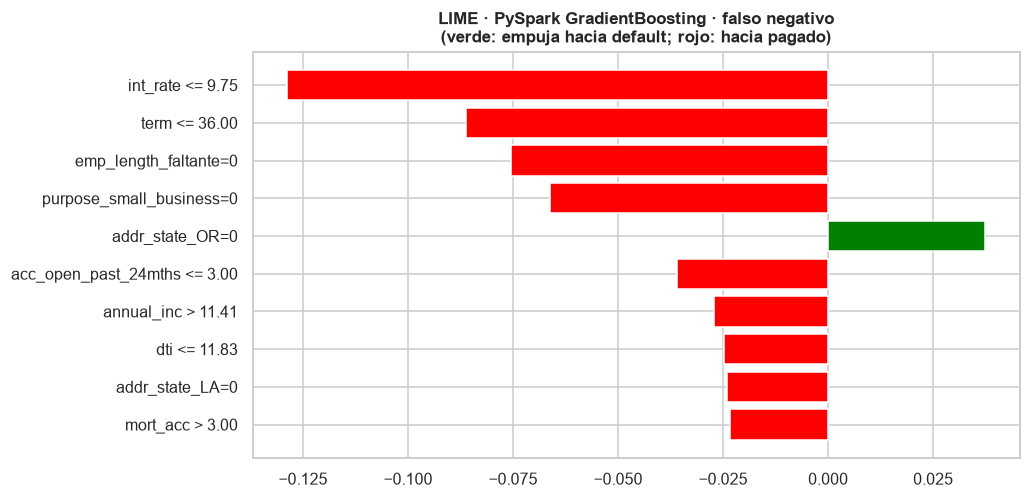

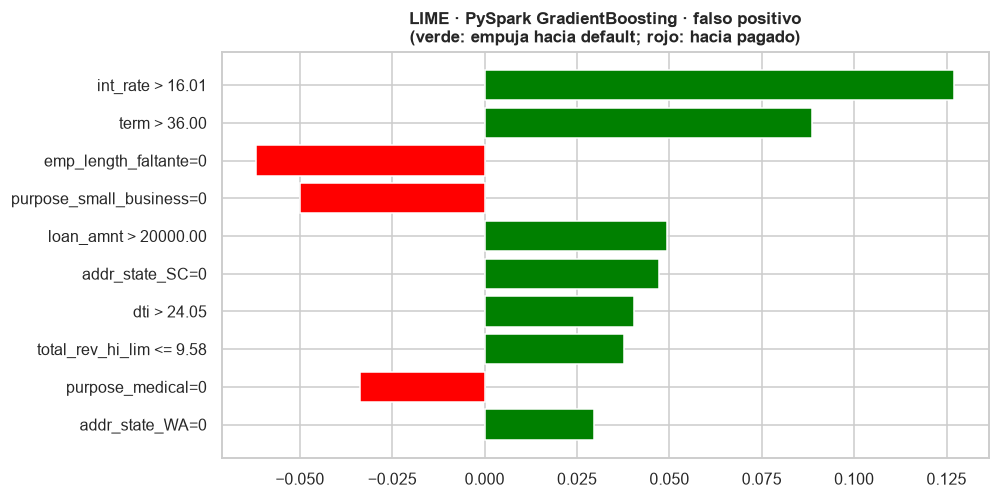

In [7]:
for tipo, ex in exp_sp.items():
    fig = ex.as_pyplot_figure(label=1)
    fig.set_size_inches(9, 4.8)
    plt.title(f"LIME · PySpark {mejor['spark']} · {tipo}\n(verde: empuja hacia default; rojo: hacia pagado)")
    u.guardar_fig(fig, f"09_lime_spark_{tipo.replace(' ', '_')}")
    plt.show()

Las explicaciones del gradient boosting de Spark destacan las mismas condiciones con pesos muy
parecidos: la tasa de interés y el plazo encabezan ambas listas, seguidos de los mismos
indicadores. Cada explicación tomó 1-2 s en Spark frente a unas centésimas de segundo en
scikit-learn (sección 9.5).

## 9.4 Comparación de las explicaciones entre entornos

In [8]:
comp = []
for tipo in exp_sk:
    a = dict(exp_sk[tipo].as_list(label=1))
    b = dict(exp_sp[tipo].as_list(label=1))
    for cond in sorted(set(a) | set(b), key=lambda c: -max(abs(a.get(c, 0)), abs(b.get(c, 0)))):
        comp.append({"instancia": tipo, "condición": cond, "peso sklearn": a.get(cond, np.nan),
                     "peso Spark": b.get(cond, np.nan)})
comp = pd.DataFrame(comp)
for tipo in exp_sk:
    s1 = set(dict(exp_sk[tipo].as_list(label=1)))
    s2 = set(dict(exp_sp[tipo].as_list(label=1)))
    print(f"{tipo}: {len(s1 & s2)} de {N_VARIABLES} condiciones en común (Jaccard {len(s1 & s2) / len(s1 | s2):.2f})")
comp.round(4)

falso negativo: 8 de 10 condiciones en común (Jaccard 0.67)
falso positivo: 6 de 10 condiciones en común (Jaccard 0.43)


,instancia,condición,peso sklearn,peso Spark
0,falso negativo,int_rate <= 9.75,-0.1250,-0.1287
1,falso negativo,term <= 36.00,-0.0825,-0.0862
2,falso negativo,emp_length_faltante=0,-0.0600,-0.0754
3,falso negativo,purpose_small_business=0,-0.0473,-0.0663
4,falso negativo,addr_state_OR=0,0.0484,0.0373
5,falso negativo,acc_open_past_24mths <= 3.00,NaN,-0.0359
6,falso negativo,addr_state_LA=0,-0.0284,-0.0240
7,falso negativo,annual_inc > 11.41,-0.0268,-0.0271
8,falso negativo,mort_acc > 3.00,-0.0257,-0.0233
9,falso negativo,dti <= 11.83,NaN,-0.0248


En el falso negativo, 8 de las 10 condiciones coinciden entre entornos; en el falso positivo, 6.
Las diferencias son sobre todo de umbral (`int_rate > 15.99` frente a `> 16.01`, `dti > 24.04`
frente a `> 24.05`), porque los cuartiles se calculan con el millón de filas en scikit-learn y
con la muestra de 50.000 en Spark, y de categorías one-hot de bajo peso (estados,
`home_ownership_OTHER`), más dos condiciones que solo aparecen en Spark
(`acc_open_past_24mths <= 3.00` en el falso negativo y `purpose_medical=0` en el falso positivo).
Los dos modelos, dos implementaciones del mismo algoritmo, reciben explicaciones parecidas en las
condiciones principales aunque no idénticas, lo que sugiere que aprendieron una estructura muy
similar.

## 9.5 Estabilidad de LIME

LIME es aleatorio: cada ejecución genera perturbaciones distintas. Se repite la explicación del
falso negativo con el modelo de scikit-learn y cinco semillas diferentes, y se mide cuántas de las
10 variables principales se repiten.

In [9]:
tops = []
x = desescalar(d["X_test"][[pos[casos["id"].iloc[0]]]])[0]
for semilla in range(5):
    e = LimeTabularExplainer(desescalar(d["X_train"]), feature_names=nombres, class_names=["pagado", "default"],
                             categorical_features=categoricas, discretize_continuous=True,
                             discretizer="quartile", random_state=semilla, mode="classification")
    ex = e.explain_instance(x, predecir_sk, num_features=N_VARIABLES, num_samples=N_MUESTRAS_LIME)
    tops.append([c for c, _ in ex.as_list(label=1)])
frecuencia = pd.Series([c for t in tops for c in t]).value_counts()
print("Condiciones que aparecen en las 5 ejecuciones:", int((frecuencia == 5).sum()), "de", N_VARIABLES)
frecuencia.to_frame("ejecuciones en que aparece (de 5)")

Condiciones que aparecen en las 5 ejecuciones: 5 de 10


,ejecuciones en que aparece (de 5)
int_rate <= 9.75,5
term <= 36.00,5
emp_length_faltante=0,5
purpose_small_business=0,5
dti <= 11.79,5
addr_state_OR=0,4
mort_acc > 3.00,4
fico_range_high > 714.00,3
annual_inc > 11.41,3
addr_state_CO=0,3


Con cinco semillas distintas solo 5 de las 10 condiciones aparecen en todas las ejecuciones:
cuatro de las de mayor peso (tasa, plazo, antigüedad laboral informada y propósito) y `dti`. Otras
condiciones, como `addr_state_OR=0` (cuarta en peso en la explicación principal), FICO o el
ingreso, entran y salen según la muestra de perturbaciones. Es una limitación conocida de LIME:
las explicaciones son estables en lo esencial e inestables en los detalles.

In [10]:
tl = pd.Series({f"{e} · {t}": v for (e, t), v in t_lime.items()}, name="segundos por explicación")
u.guardar_json({f"{e}|{t}": v for (e, t), v in t_lime.items()}, u.RESULTADOS / "tiempos_lime.json")
datos["train"].unpersist()
datos["test"].unpersist()
spark.stop()
tl.round(2)

sklearn · falso negativo    0.03
sklearn · falso positivo    0.02
spark · falso negativo      1.88
spark · falso positivo      1.09
Name: segundos por explicación, dtype: float64

## 9.6 Aporte y limitaciones de LIME

**Aporte.** En los dos préstamos analizados, LIME mostró que los dos mejores modelos se apoyan
sobre todo en razones coherentes con el dominio (tasa, plazo, capacidad de pago) y que estos
errores corresponden a préstamos cuyo desenlace contradijo un perfil típico, no a reglas
espurias. Con dos instancias no se puede generalizar a todas las decisiones de los modelos. Como
es agnóstico al modelo, sirvió igual para scikit-learn y para PySpark.

**Limitaciones generales.** (i) La explicación depende de cómo se definen la vecindad y la
discretización (aquí, cuartiles), y el $R^2$ local de 0,45 a 0,54 indica que el modelo lineal
solo aproxima parcialmente al gradient boosting. (ii) Es aleatoria: la mitad de las condiciones
cambia entre semillas. (iii) Las perturbaciones se generan variable por variable, ignorando
correlaciones (puede crear préstamos con tasa baja y calificación mala, que no existen) y
tratando cada columna one-hot por separado, lo que produce condiciones poco interpretables como
`addr_state_OR=0`.

**Limitaciones en entornos distribuidos.** LIME opera en la memoria local de un solo proceso:
(i) necesita los datos de referencia en el driver, así que con Spark hubo que transferir una
muestra de 50.000 filas (no el millón completo), lo que cambia ligeramente los cuartiles y, por
tanto, las condiciones; (ii) cada explicación evalúa el modelo 5.000 veces, y en Spark eso exige
crear un DataFrame, programar un trabajo distribuido y traer los resultados al driver, lo que
hace cada explicación entre 55 y 65 veces más lenta que en scikit-learn (1,1-1,9 s frente a
0,02-0,03 s); explicar miles de préstamos con Spark sería costoso; (iii) la explicación de una instancia no
se paraleliza naturalmente, y paralelizar muchas instancias exigiría distribuir el modelo y el
explicador a los ejecutores, algo que LIME no ofrece.